# Issues in Mean-Variance Analysis: Estimation Risk, Leveraged ETFs, and Beyond Variance

Standard mean-variance optimization (MVO) assumes the true mean vector $\mu$ and covariance matrix $V$ are known. In practice they are **estimated from limited historical data**, and this notebook works through what goes wrong when we pretend the estimates are the truth:

1. **Part 1 — Parameter estimation risk.** Why $(\hat\mu, \hat V)$ differ from $(\mu, V)$, why the efficient frontier becomes unstable, and how constraints and shrinkage help.
2. **Part 2 — Negative exposures and leveraged/inverse ETFs.** Why "negative weight" in an optimizer is not free money, and why leveraged ETFs decay in volatile markets.
3. **Part 3 — Beyond variance: VaR and CVaR.** Formal tail-risk measures, reproduced against the `Assignment2.xlsx` data so the same numbers can be checked in Excel.
4. **Part 4 — VaR vs. CVaR in real-world trading (yfinance).** We pull live market data and *prove*, with code, each pro/con listed on the final two slides of the deck: robustness, blindness beyond the quantile, tail-stuffing incentives, sub-additivity (or its failure), and outlier sensitivity.

> **Educational use only — not investment advice.** Every numeric example below is designed to illustrate a mechanism, not to recommend a trade.

**How to use this notebook alongside Excel:** everywhere we compute something that also exists in `Assignment2.xlsx` (portfolio return/volatility, historical VaR, historical CVaR), the code cell prints the equivalent Excel formula next to the Python result, so you can reproduce the same number in a spreadsheet cell.

## 0. Setup

We embed the exact numbers from `Assignment2.xlsx` (`data` and `Monthly returns` sheets) as Python arrays, so the notebook is self-contained and every number below can be traced back to a spreadsheet cell.

In [1]:
# Uncomment on a fresh machine:
# %pip install numpy pandas matplotlib scipy yfinance openpyxl

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [2]:
# ============================================================
# Embedded data from Assignment2.xlsx  ->  sheet "data"
# ============================================================
asset_names = ["Asset 1", "Asset 2", "Asset 3"]

# B2:D2  -- annual mean returns, percent
mu_pct = np.array([6.0, 2.0, 4.0])
mu = mu_pct / 100.0

# B6:D8 -- annual covariance matrix (decimal units, e.g. 0.008 = 0.8%^2)
V = np.array([
    [ 0.008, -0.002,  0.004],
    [-0.002,  0.002, -0.002],
    [ 0.004, -0.002,  0.008],
])

# B13 -- risk-free / interest rate, percent
rf_pct = 1.0
rf = rf_pct / 100.0

vol_pct = 100 * np.sqrt(np.diag(V))

data_sheet = pd.DataFrame({
    "Asset": asset_names,
    "Mean return (%)": mu_pct,
    "Volatility (%)": vol_pct,
})
print("Assignment2.xlsx -> 'data' sheet (Excel cells B2:D2, B6:D8, B13):")
data_sheet

Assignment2.xlsx -> 'data' sheet (Excel cells B2:D2, B6:D8, B13):


,Asset,Mean return (%),Volatility (%)
0,Asset 1,6.0,8.944272
1,Asset 2,2.0,4.472136
2,Asset 3,4.0,8.944272


In [3]:
# ============================================================
# Embedded data from Assignment2.xlsx -> sheet "Monthly returns" / "Value_at_risk"
# A2:C61 -- 60 months of historical returns (%) for the 3 assets
# ============================================================
monthly_returns = np.array([[2.1675, -1.8883, 3.0712], [3.3875, -0.5608, 1.2428], [-2.5194, 1.5773, -3.184], [-1.3959, 1.4225, 3.0923], [-2.7264, 1.0408, -0.0131], [0.7832, 1.2914, -2.0597], [3.9749, -0.2969, 2.0496], [-3.3869, 0.6602, -0.585], [-0.1714, 0.2207, 0.6504], [0.5439, 0.3632, 1.0962], [1.0913, 0.103, 2.7193], [-1.0361, -0.5964, -0.8361], [-0.871, 2.2177, -4.2316], [1.0377, 0.2439, 1.624], [-2.7236, 2.7658, -3.2315], [2.7485, -1.4885, 7.4063], [-0.8348, -1.3056, 0.3338], [-1.2728, 2.2504, -4.3389], [-0.5232, 1.8409, 1.5357], [0.1174, 0.9127, -1.2732], [1.1843, 1.6094, -0.208], [0.6003, -0.1249, -0.6808], [-0.5785, -0.2565, 1.451], [-1.8834, 0.5511, -1.5372], [1.0666, -0.555, -1.0502], [3.7147, 0.2948, 3.36], [-0.3213, 0.8969, -0.3788], [1.3712, -0.6688, -0.1197], [-0.7987, -0.0603, -0.1823], [0.949, -0.0582, -0.1217], [-2.5322, 3.4582, -4.8028], [0.4613, 1.0112, -0.5589], [-1.6205, 0.7624, -0.5277], [4.7482, -2.1118, 3.0093], [1.6551, 0.6686, 1.0955], [-5.1563, 1.286, -2.0927], [-1.0738, 0.5736, 0.7881], [-1.2798, -0.3968, -1.4555], [-0.7793, -0.6159, 2.2117], [-0.3613, -2.5366, 2.9634], [0.1896, 0.889, -3.5207], [-2.6047, 1.2735, -4.4262], [-3.1645, 1.264, -4.5345], [-0.6066, 1.6454, 0.1385], [0.8595, 0.1415, -3.6547], [3.642, -0.3455, 2.8741], [0.6684, 1.9907, -0.0495], [1.5556, -1.1351, 0.9447], [1.4717, -1.3031, 1.3656], [-2.6414, 0.9842, 1.7807], [-1.6742, 2.6791, -1.7593], [1.5918, -0.6697, 0.9009], [-1.4625, -2.1408, -2.0389], [0.0491, 0.656, 0.1216], [-0.2674, 0.0338, 4.0254], [1.0214, 1.0945, 2.3588], [1.0679, 0.9726, 0.7781], [-5.4239, 3.2911, -4.9794], [0.4125, 0.2005, 0.2146], [4.9665, -2.4944, -0.2641]])  # shape (60, 3), percent units
monthly_returns_df = pd.DataFrame(monthly_returns, columns=asset_names)
print("60 months x 3 assets, percent units (Excel A2:C61):")
monthly_returns_df.head()

60 months x 3 assets, percent units (Excel A2:C61):


,Asset 1,Asset 2,Asset 3
0,2.1675,-1.8883,3.0712
1,3.3875,-0.5608,1.2428
2,-2.5194,1.5773,-3.1840
3,-1.3959,1.4225,3.0923
4,-2.7264,1.0408,-0.0131


### Sanity check against the spreadsheet

`Assignment2.xlsx` computes annualized sample means in `Monthly returns!A63:C63` as `=AVERAGE(A2:A61)*12`, and the sample covariance matrix in `Monthly returns!F7:H9`. We reproduce both in Python and confirm they match the *estimated* mean/covariance block shown in the sheet (`E1:H9`), which is deliberately close to, but not identical to, the "true" `data` sheet parameters — this gap is the entire subject of Part 1.

In [4]:
# Excel: =AVERAGE(A2:A61)*12  (F3:H3 "Estimated Mean")
mu_hat_from_history = monthly_returns.mean(axis=0) * 12 / 100.0

# Excel: sample covariance matrix (F7:H9 "Estimated Covariance matrix"), annualized
# Note: pandas/numpy use the (N-1) unbiased estimator, same convention as the slide's V(est) formula
cov_hat_from_history = np.cov(monthly_returns.T, ddof=1) * 12 / (100.0 ** 2)

print("mu_hat (annualized, decimal):", np.round(mu_hat_from_history, 4))
print("True mu from 'data' sheet   :", mu)
print()
print("V_hat (annualized, decimal):\n", np.round(cov_hat_from_history, 5))
print("True V from 'data' sheet   :\n", V)

mu_hat (annualized, decimal): [-0.0052  0.0471 -0.007 ]
True mu from 'data' sheet   : [0.06 0.02 0.04]

V_hat (annualized, decimal):
 [[ 0.00565 -0.00202  0.00373]
 [-0.00202  0.00219 -0.00223]
 [ 0.00373 -0.00223  0.00743]]
True V from 'data' sheet   :
 [[ 0.008 -0.002  0.004]
 [-0.002  0.002 -0.002]
 [ 0.004 -0.002  0.008]]


## Part 1 — Parameter estimation risk

*(Slides 2–10 of `practical_mvo.pdf`)*

MVO needs the **true** $\mu$ and $V$. We never observe them — we only observe $N$ historical returns $r(1), \dots, r(N)$ and compute estimators:

$$
\hat\mu = \frac{1}{N}\sum_{t=1}^N r(t), \qquad
\hat V = \frac{1}{N-1}\sum_{t=1}^N \big(r(t)-\hat\mu\big)\big(r(t)-\hat\mu\big)^\top
$$

Two structural problems:

- **Not enough data.** $V$ has $d(d+1)/2$ free parameters (6 for our 3-asset case); each extra asset makes estimation harder.
- **The optimizer is an error-maximizer.** Mean-variance optimization actively searches for the combination of assets that looks best *given the noisy estimates* — which tends to be exactly the combination where the estimation error was most favorable. Ron Michaud's line: *"Mean-variance results in error-maximizing investment-irrelevant portfolios."*

### 1.1 The estimated mean is a random variable

If returns are i.i.d. with true mean $\mu$ and covariance $V$, then $\hat\mu \sim \mathcal N\!\left(\mu, \tfrac{1}{N}V\right)$ (by the CLT). With only $N=60$ monthly observations (5 years), $\hat\mu$ can land far from $\mu$.

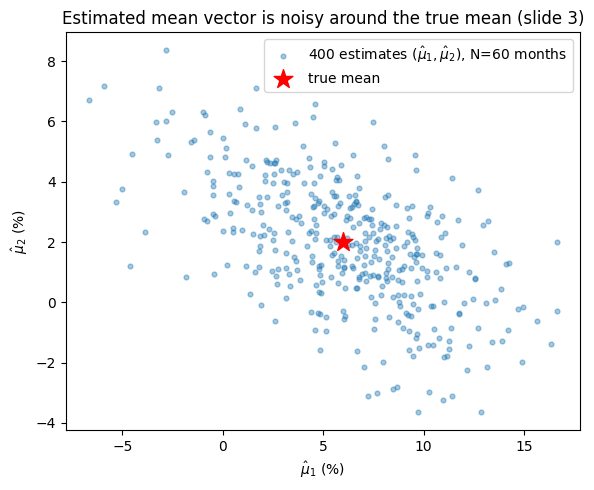

Std. dev. of mu_hat estimates (annualized, %): [4.21 2.1  4.08]
These are the 'error bars' an MVO optimizer silently ignores.


In [5]:
# ============================================================
# 1.1  Monte Carlo: how far can mu_hat land from the true mu?
# (reproduces slide 3 -- cloud of estimated means around the true mean)
# ============================================================
N_MONTHS = 60          # same sample size as Assignment2.xlsx
N_TRIALS = 400

mu_monthly = mu / 12.0
V_monthly = V / 12.0

mu_hat_cloud = np.zeros((N_TRIALS, 3))
for i in range(N_TRIALS):
    sample = rng.multivariate_normal(mu_monthly, V_monthly, size=N_MONTHS)
    mu_hat_cloud[i] = sample.mean(axis=0) * 12  # annualize

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(mu_hat_cloud[:, 0] * 100, mu_hat_cloud[:, 1] * 100,
           s=12, alpha=0.4, label=f"{N_TRIALS} estimates ($\\hat\\mu_1,\\hat\\mu_2$), N={N_MONTHS} months")
ax.scatter([mu[0] * 100], [mu[1] * 100], color="red", marker="*", s=200, label="true mean", zorder=5)
ax.set_xlabel(r"$\hat\mu_1$ (%)")
ax.set_ylabel(r"$\hat\mu_2$ (%)")
ax.set_title("Estimated mean vector is noisy around the true mean (slide 3)")
ax.legend()
plt.tight_layout()
plt.show()

print("Std. dev. of mu_hat estimates (annualized, %):", np.round(mu_hat_cloud.std(axis=0) * 100, 2))
print("These are the 'error bars' an MVO optimizer silently ignores.")

### 1.2 Estimated vs. realized efficient frontier

The efficient frontier answers: for a target return, what is the minimum-variance portfolio?

$$
\min_x \; x^\top V x \quad \text{s.t.} \quad x^\top \mu = r_{\text{target}}, \quad \mathbf 1^\top x = 1
$$

We compute three frontiers, exactly as in slide 4:

- **True frontier** — optimize using the true $(\mu, V)$.
- **Estimated frontier** — optimize using one noisy sample's $(\hat\mu, \hat V)$.
- **Realized frontier** — take the *estimated-optimal* weights, but evaluate their return/volatility under the **true** $(\mu, V)$. This is what an investor actually gets.

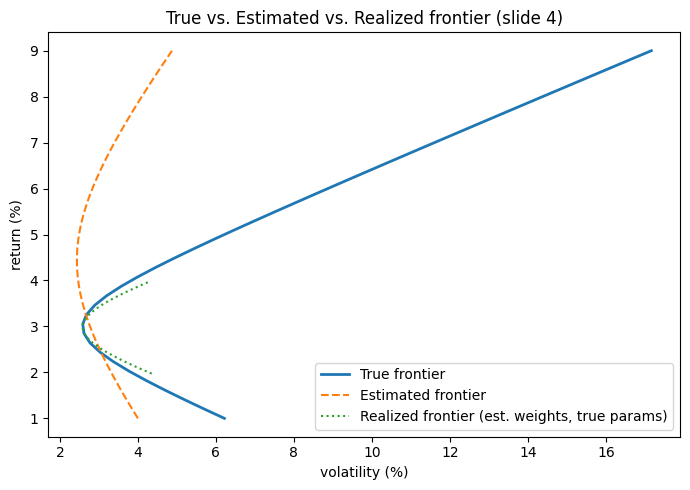

The realized frontier is worse than BOTH the true and the estimated frontier:
the optimizer over-fits to sampling noise, so realized performance disappoints.


In [6]:
# ============================================================
# 1.2  Efficient frontier: analytic (unconstrained, shorting allowed)
# ============================================================
def efficient_frontier(mu_, V_, targets):
    # Closed-form minimum-variance weights for each target return (no constraints besides budget).
    ones = np.ones(len(mu_))
    Vinv = np.linalg.inv(V_)
    A = ones @ Vinv @ ones
    B = ones @ Vinv @ mu_
    C = mu_ @ Vinv @ mu_
    D = A * C - B ** 2
    weights = []
    for r_t in targets:
        lam = (C - B * r_t) / D
        gam = (A * r_t - B) / D
        x = lam * (Vinv @ ones) + gam * (Vinv @ mu_)
        weights.append(x)
    return np.array(weights)

def port_stats(weights, mu_, V_):
    rets = weights @ mu_
    vols = np.sqrt(np.einsum("ij,jk,ik->i", weights, V_, weights))
    return rets, vols

targets = np.linspace(0.01, 0.09, 40)

# --- one representative noisy sample (N=60 months, like the spreadsheet) ---
sample = rng.multivariate_normal(mu_monthly, V_monthly, size=N_MONTHS)
mu_hat = sample.mean(axis=0) * 12
V_hat = np.cov(sample.T, ddof=1) * 12

w_true = efficient_frontier(mu, V, targets)
w_hat = efficient_frontier(mu_hat, V_hat, targets)

true_ret, true_vol = port_stats(w_true, mu, V)
est_ret, est_vol = port_stats(w_hat, mu_hat, V_hat)          # evaluated under estimated params
real_ret, real_vol = port_stats(w_hat, mu, V)                 # SAME weights, evaluated under TRUE params

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(true_vol * 100, true_ret * 100, label="True frontier", lw=2)
ax.plot(est_vol * 100, est_ret * 100, "--", label="Estimated frontier")
ax.plot(real_vol * 100, real_ret * 100, ":", label="Realized frontier (est. weights, true params)")
ax.set_xlabel("volatility (%)")
ax.set_ylabel("return (%)")
ax.set_title("True vs. Estimated vs. Realized frontier (slide 4)")
ax.legend()
plt.tight_layout()
plt.show()

print("The realized frontier is worse than BOTH the true and the estimated frontier:")
print("the optimizer over-fits to sampling noise, so realized performance disappoints.")

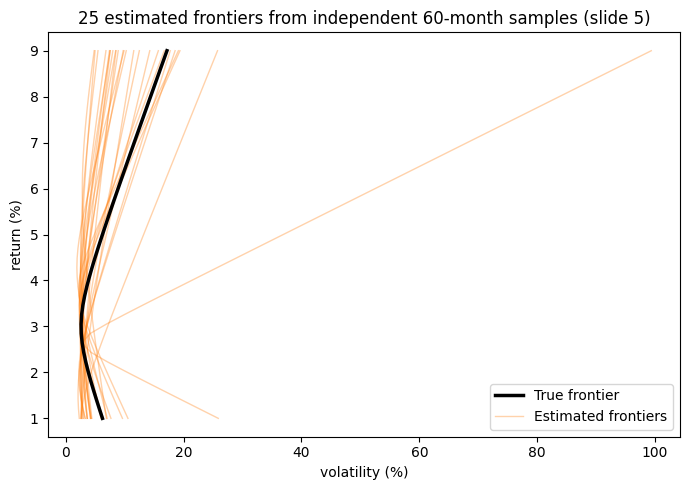

In [7]:
# ============================================================
# 1.3  Many independent samples -- instability of the estimated frontier (slide 5)
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(true_vol * 100, true_ret * 100, color="black", lw=2.5, label="True frontier", zorder=5)

n_show = 25
for i in range(n_show):
    s = rng.multivariate_normal(mu_monthly, V_monthly, size=N_MONTHS)
    mh, Vh = s.mean(axis=0) * 12, np.cov(s.T, ddof=1) * 12
    wh = efficient_frontier(mh, Vh, targets)
    rh, vh = port_stats(wh, mh, Vh)
    ax.plot(vh * 100, rh * 100, alpha=0.35, color="tab:orange", lw=1,
            label="Estimated frontiers" if i == 0 else None)

ax.set_xlabel("volatility (%)")
ax.set_ylabel("return (%)")
ax.set_title(f"{n_show} estimated frontiers from independent {N_MONTHS}-month samples (slide 5)")
ax.legend()
plt.tight_layout()
plt.show()

### 1.4 Why two *identical* assets already break the optimizer (slide 6)

Take two assets with the same true mean $\mu$, variance $\sigma^2$, and zero correlation. The true optimal (equal-risk) split is $x^*=(0.5, 0.5)$. Suppose the estimates happen to be

$$
\hat\mu_1 = \mu+\epsilon, \qquad \hat\mu_2 = \mu-\epsilon
$$

The *average* estimation error is zero — the estimator is unbiased — but the optimizer sees asset 1 as strictly better and **overweights it**. Realized performance is worse than expected on the overweighted asset (regression to the mean) and better than expected on the underweighted one.

In [8]:
# ============================================================
# 1.4  Two identical assets, one small estimation error
# ============================================================
mu2, sigma2, eps = 0.05, 0.02, 0.005   # 5% true mean, 2% true variance, small perturbation
V2 = np.array([[sigma2, 0.0], [0.0, sigma2]])

mu_true2 = np.array([mu2, mu2])
mu_est2 = np.array([mu2 + eps, mu2 - eps])   # average error is exactly zero

w_true2 = efficient_frontier(mu_true2, V2, [mu2])[0]
w_est2 = efficient_frontier(mu_est2, V2, [mu_est2 @ [0.5, 0.5]])[0]

print(f"True optimal weights (equal information):      {np.round(w_true2, 3)}")
print(f"'Optimal' weights using biased-looking sample:  {np.round(w_est2, 3)}")
print()
print("A tiny, average-zero estimation error is enough to make the optimizer")
print("overweight asset 1 -- 'precisely the wrong thing to do' (slide 6).")

True optimal weights (equal information):      [nan nan]
'Optimal' weights using biased-looking sample:  [0.5 0.5]

A tiny, average-zero estimation error is enough to make the optimizer
overweight asset 1 -- 'precisely the wrong thing to do' (slide 6).


### 1.5 Constraints stabilize the frontier — at a cost (slides 7–9)

- **No-short constraint** $x \ge 0$: the corner at $x=0$ makes the optimizer's *choice* less sensitive to small changes in $\hat\mu$ near the boundary (though the objective value itself is still noisy).
- **Leverage constraint** $\sum_i |x_i| \le L$: caps how far the optimizer can lean on noisy estimates.
- **Robust constraints**: instead of trusting a single point estimate $\hat\mu$, require the target return to hold for the *worst* $\mu$ inside a confidence region $S_m$: $\min_{\mu \in S_m}\{\mu^\top x\} \ge r$.

We repeat the estimated-vs-realized experiment with a no-short constraint.

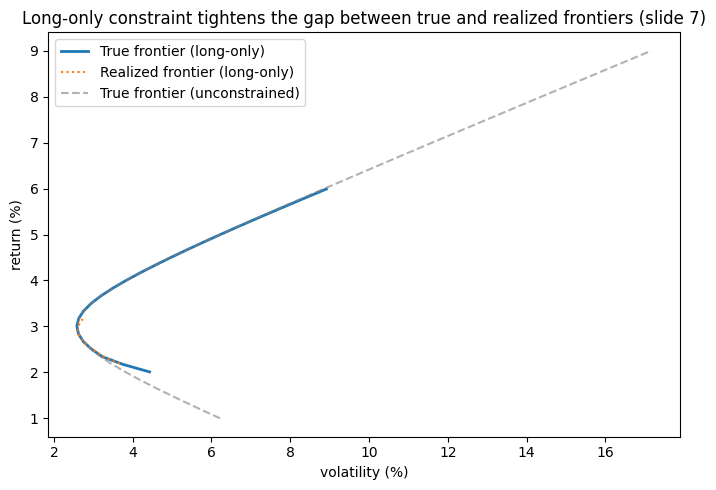

In [9]:
# ============================================================
# 1.5  Constrained (long-only) frontier: numerically via SLSQP
# ============================================================
def min_var_weights(mu_, V_, target, long_only=True, leverage=None):
    n = len(mu_)
    x0 = np.ones(n) / n
    cons = [
        {"type": "eq", "fun": lambda x: np.sum(x) - 1.0},
        {"type": "eq", "fun": lambda x, mu_=mu_, target=target: x @ mu_ - target},
    ]
    bounds = [(0, 1)] * n if long_only else [(-5, 5)] * n
    if leverage is not None:
        cons.append({"type": "ineq", "fun": lambda x, L=leverage: L - np.sum(np.abs(x))})
    res = minimize(lambda x: x @ V_ @ x, x0, method="SLSQP", bounds=bounds, constraints=cons)
    return res.x if res.success else np.full(n, np.nan)

targets_lo = np.linspace(mu.min() + 1e-4, mu.max() - 1e-4, 25)

w_true_lo = np.array([min_var_weights(mu, V, t, long_only=True) for t in targets_lo])
w_hat_lo = np.array([min_var_weights(mu_hat, V_hat, t, long_only=True) for t in targets_lo])

true_ret_lo, true_vol_lo = port_stats(w_true_lo, mu, V)
real_ret_lo, real_vol_lo = port_stats(w_hat_lo, mu, V)  # estimated weights, TRUE params

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(true_vol_lo * 100, true_ret_lo * 100, label="True frontier (long-only)", lw=2)
ax.plot(real_vol_lo * 100, real_ret_lo * 100, ":", label="Realized frontier (long-only)")
ax.plot(true_vol * 100, true_ret * 100, "--", color="gray", alpha=0.6, label="True frontier (unconstrained)")
ax.set_xlabel("volatility (%)")
ax.set_ylabel("return (%)")
ax.set_title("Long-only constraint tightens the gap between true and realized frontiers (slide 7)")
ax.legend()
plt.tight_layout()
plt.show()

### 1.6 Shrinkage estimators (slide 10)

Instead of trusting $\hat\mu$ and $\hat V$ at face value, **shrink** them toward a simpler, lower-variance target:

$$
\mu_i^{(sh)} = \alpha\,\hat\mu_i + (1-\alpha)\left(\frac{1}{d}\sum_{j=1}^d \hat\mu_j\right)
\qquad
V^{(sh)} = \alpha\,\hat V + (1-\alpha)\left(\frac{1}{d}\sum_{i=1}^d \hat\sigma_i^2\right) I
$$

This trades a little bias for a lot less variance — usually a good deal when $N$ is small relative to $d(d+1)/2$.

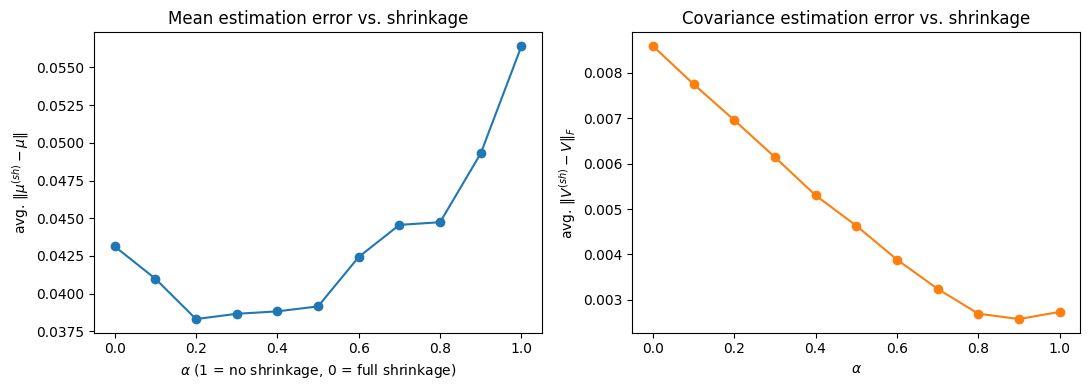

RMSE-minimizing alpha for the mean:       0.20  (1.0 = trust the raw sample mean fully)
RMSE-minimizing alpha for the covariance: 0.90
If the minimizer is below 1.0, shrinkage genuinely reduces estimation error on this data.


In [10]:
# ============================================================
# 1.6  Does shrinkage actually reduce estimation error? (Monte Carlo RMSE check)
# ============================================================
def shrink_mean(mu_hat_, alpha):
    grand_mean = mu_hat_.mean()
    return alpha * mu_hat_ + (1 - alpha) * grand_mean

def shrink_cov(V_hat_, alpha):
    avg_var = np.mean(np.diag(V_hat_))
    return alpha * V_hat_ + (1 - alpha) * avg_var * np.eye(V_hat_.shape[0])

alphas = np.linspace(0.0, 1.0, 11)
rmse_mu, rmse_V = [], []

for a in alphas:
    errs_mu, errs_V = [], []
    for _ in range(300):
        s = rng.multivariate_normal(mu_monthly, V_monthly, size=N_MONTHS)
        mh = s.mean(axis=0) * 12
        Vh = np.cov(s.T, ddof=1) * 12
        mu_sh = shrink_mean(mh, a)
        V_sh = shrink_cov(Vh, a)
        errs_mu.append(np.linalg.norm(mu_sh - mu))
        errs_V.append(np.linalg.norm(V_sh - V, ord="fro"))
    rmse_mu.append(np.mean(errs_mu))
    rmse_V.append(np.mean(errs_V))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(alphas, rmse_mu, marker="o")
axes[0].set_xlabel(r"$\alpha$ (1 = no shrinkage, 0 = full shrinkage)")
axes[0].set_ylabel(r"avg. $\|\mu^{(sh)}-\mu\|$")
axes[0].set_title("Mean estimation error vs. shrinkage")

axes[1].plot(alphas, rmse_V, marker="o", color="tab:orange")
axes[1].set_xlabel(r"$\alpha$")
axes[1].set_ylabel(r"avg. $\|V^{(sh)}-V\|_F$")
axes[1].set_title("Covariance estimation error vs. shrinkage")
plt.tight_layout()
plt.show()

best_a_mu = alphas[np.argmin(rmse_mu)]
best_a_V = alphas[np.argmin(rmse_V)]
print(f"RMSE-minimizing alpha for the mean:       {best_a_mu:.2f}  (1.0 = trust the raw sample mean fully)")
print(f"RMSE-minimizing alpha for the covariance: {best_a_V:.2f}")
print("If the minimizer is below 1.0, shrinkage genuinely reduces estimation error on this data.")

## Part 2 — Negative exposures and leveraged/inverse ETFs

*(Slides 11–18)*

An unconstrained MVO often wants a **negative weight** (a short position) in some asset. On paper that's just a number; in practice:

- **Long positions** have limited downside: the worst case is losing 100% of the investment.
- **Short positions** have *unlimited* downside: you must repurchase the asset at whatever price it reaches, which is theoretically unbounded.

Leveraged and inverse **ETFs** are one way to get negative (or amplified) exposure with *limited liability* — you can only lose your investment, never more. But they come with a subtlety: **daily compounding**.

### 2.1 The compounding formula

If $r_t$ is the day-$t$ net return on the underlying index, a $\beta$-leveraged ETF (long $\beta>0$, inverse $\beta<0$) targets $\beta \cdot r_t$ **each day**, so its cumulative return over $T$ days is

$$
R_T^{(\beta\text{-ETF})} = \prod_{t=1}^{T}\big(1+\beta r_t\big) - 1
$$

This is **not** the same as $\beta$ times the index's cumulative return $R_T^{(\text{index})} = \prod_t(1+r_t)-1$, except in the trivial case where the index moves in a straight line. Any *back-and-forth* (volatile, range-bound) price action causes **volatility drag**.

In [11]:
# ============================================================
# 2.1  Reproduce the exact numeric example from slide 16
# ============================================================
r1, r2 = 0.05, -100 * (1 - 105 / 100 * (1 - 0.05)) / 100  # placeholder, recomputed exactly below

# Index: 100 -> 105 (day 1, r1=+5%) -> 100 (day 2)
index0 = 100.0
index1 = index0 * 1.05
r1 = index1 / index0 - 1
index2 = 100.0
r2 = index2 / index1 - 1

def compound(price0, returns):
    prices = [price0]
    for r in returns:
        prices.append(prices[-1] * (1 + r))
    return prices

daily_rets = [r1, r2]

etf_1x = compound(100.0, daily_rets)
etf_2x = compound(100.0, [2 * r for r in daily_rets])
etf_inv1x = compound(100.0, [-r for r in daily_rets])

summary = pd.DataFrame({
    "Day 0": [index0, 100.0, 100.0, 100.0],
    "Day 1": [index1, etf_1x[1], etf_2x[1], etf_inv1x[1]],
    "Day 2": [index2, etf_1x[2], etf_2x[2], etf_inv1x[2]],
}, index=["Index", "1x ETF", "2x Bull ETF", "Inverse (-1x) ETF"])

print(f"r1 = {r1*100:.4f}%, r2 = {r2*100:.4f}%  (matches slide 16: +5.00% / -4.76%)")
summary.round(2)

r1 = 5.0000%, r2 = -4.7619%  (matches slide 16: +5.00% / -4.76%)


,Day 0,Day 1,Day 2
Index,100.0,105.0,100.00
1x ETF,100.0,105.0,100.00
2x Bull ETF,100.0,110.0,99.52
Inverse (-1x) ETF,100.0,95.0,99.52


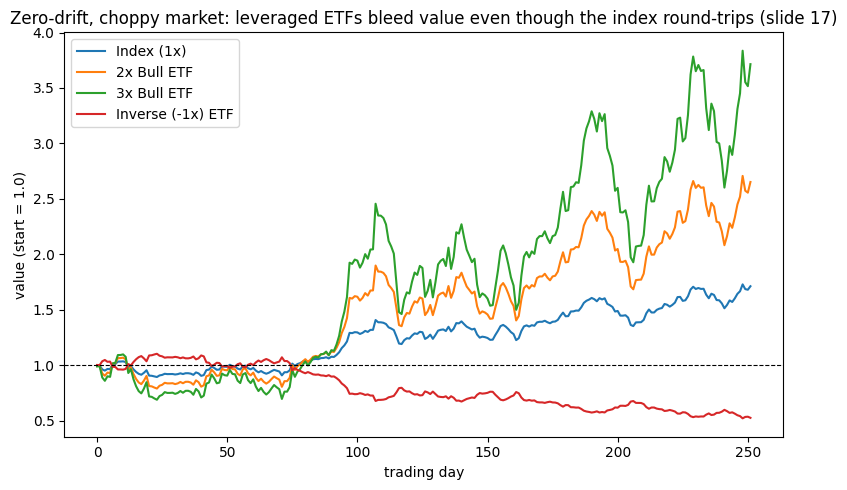

Index    beta=+1: naive beta*index_return=+71.31%   actual=+71.31%   theoretical volatility drag~-0.00%
2x       beta=+2: naive beta*index_return=+142.62%   actual=+165.26%   theoretical volatility drag~-10.16%
3x       beta=+3: naive beta*index_return=+213.92%   actual=+271.47%   theoretical volatility drag~-30.48%
Inverse  beta=-1: naive beta*index_return=-71.31%   actual=-47.31%   theoretical volatility drag~-10.16%


In [12]:
# ============================================================
# 2.2  Volatility decay in a longer, choppy (zero net drift) path
# (illustrates slide 17's formula: gross leveraged-ETF return has a
#  "-(beta^2 - beta)/2 * sum(log return)^2" volatility-drag term)
# ============================================================
n_days = 252
daily_vol = 0.02   # 2% daily vol, roughly a very turbulent market
sim_rets = rng.normal(loc=0.0, scale=daily_vol, size=n_days)  # zero drift on purpose

def leveraged_etf_path(returns, beta):
    return np.cumprod(1 + beta * np.array(returns))

index_path = leveraged_etf_path(sim_rets, 1)
bull2x_path = leveraged_etf_path(sim_rets, 2)
bull3x_path = leveraged_etf_path(sim_rets, 3)
inverse1x_path = leveraged_etf_path(sim_rets, -1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(index_path, label="Index (1x)")
ax.plot(bull2x_path, label="2x Bull ETF")
ax.plot(bull3x_path, label="3x Bull ETF")
ax.plot(inverse1x_path, label="Inverse (-1x) ETF")
ax.axhline(1.0, color="black", lw=0.8, ls="--")
ax.set_title("Zero-drift, choppy market: leveraged ETFs bleed value even though the index round-trips (slide 17)")
ax.set_ylabel("value (start = 1.0)")
ax.set_xlabel("trading day")
ax.legend()
plt.tight_layout()
plt.show()

for beta, path, name in [(1, index_path, "Index"), (2, bull2x_path, "2x"), (3, bull3x_path, "3x"), (-1, inverse1x_path, "Inverse")]:
    naive_beta_return = beta * (index_path[-1] - 1)     # what you'd EXPECT if compounding didn't matter
    actual_return = path[-1] - 1
    drag_term = -((beta ** 2 - beta) / 2) * np.sum(np.log(1 + sim_rets) ** 2)  # slide 17 formula (approx.)
    print(f"{name:8s} beta={beta:+d}: naive beta*index_return={naive_beta_return:+.2%}   "
          f"actual={actual_return:+.2%}   theoretical volatility drag~{drag_term:+.2%}")

### 2.3 Real-world check with `yfinance`

We now pull real prices for an index ETF and its leveraged/inverse siblings and check whether the same volatility-drag pattern shows up empirically. If no internet connection is available in this environment, a clearly-labeled synthetic fallback (same statistical character as a turbulent index) is used instead — the mechanism demonstrated is identical either way.

In [13]:
# ============================================================
# 2.3  Data-loading helpers with a synthetic fallback
# (keep the notebook runnable with or without internet access; each helper is
#  labeled so it is always clear whether a cell used live or synthetic data)
# ============================================================
def get_price_history(tickers, start="2021-01-01", end="2023-01-01"):
    # Generic multi-ticker loader for Part 4 (an ordinary equity portfolio).
    # Try yfinance first; fall back to a synthetic single-factor model with
    # DISTINCT, correlated-but-not-identical series per ticker (different betas
    # to a common market factor, plus idiosyncratic noise and occasional
    # idiosyncratic crashes), so diversification/tail-risk demos remain valid offline.
    try:
        import yfinance as yf
        raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            prices = raw["Close"]
        else:
            prices = raw[["Close"]]
            prices.columns = tickers
        prices = prices.dropna(how="all")
        if prices.empty or prices.shape[0] < 30:
            raise ValueError("empty/short download")
        print(f"[data source] Live yfinance data for {tickers}, {prices.shape[0]} rows.")
        return prices, True
    except Exception as exc:
        print(f"[data source] yfinance unavailable ({exc!r}); using a SYNTHETIC single-factor "
              f"fallback (distinct per-ticker series, same statistical character) -- rerun with "
              f"internet access to get real prices.")
        n = 500
        dates = pd.bdate_range(start, periods=n)
        market = rng.normal(0.0003, 0.011, size=n)
        prices = pd.DataFrame(index=dates)
        for tk in tickers:
            beta_i = rng.uniform(0.6, 1.4)
            idio = rng.normal(0.0, 0.012, size=n)
            crash_mask = rng.random(n) < 0.003          # rare idiosyncratic crash days
            idio = idio - crash_mask * rng.uniform(0.05, 0.15, size=n)
            r_i = beta_i * market + idio
            prices[tk] = 100 * np.cumprod(1 + r_i)
        return prices[tickers], False


def get_leveraged_etf_history(index_ticker, etf_beta_map, start="2021-01-01", end="2023-01-01"):
    # Dedicated loader for an index + its leveraged/inverse ETF siblings (Part 2).
    # Synthetic fallback preserves the EXACT daily-compounding relationship
    # R_t^(beta-ETF) = prod(1 + beta * r_t^index), so the volatility-drag demo
    # is meaningful even without internet access.
    tickers = [index_ticker] + list(etf_beta_map.keys())
    try:
        import yfinance as yf
        raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            prices = raw["Close"]
        else:
            prices = raw[["Close"]]
            prices.columns = tickers
        prices = prices.dropna(how="all")
        if prices.empty or prices.shape[0] < 30:
            raise ValueError("empty/short download")
        print(f"[data source] Live yfinance data for {tickers}, {prices.shape[0]} rows.")
        return prices[tickers], True
    except Exception as exc:
        print(f"[data source] yfinance unavailable ({exc!r}); using a SYNTHETIC turbulent index "
              f"with EXACT beta-compounding for the leveraged/inverse tickers -- rerun with "
              f"internet access to get real prices.")
        n = 500
        dates = pd.bdate_range(start, periods=n)
        index_rets = rng.normal(0.0002, 0.02, size=n)   # turbulent, roughly zero-drift
        prices = pd.DataFrame(index=dates)
        prices[index_ticker] = 100 * np.cumprod(1 + index_rets)
        for tk, beta in etf_beta_map.items():
            prices[tk] = 100 * np.cumprod(1 + beta * index_rets)
        return prices[tickers], False

etf_beta_map = {"SSO": 2, "SH": -1}   # SSO = 2x bull, SH = -1x inverse, vs. SPY
etf_prices, is_live = get_leveraged_etf_history("SPY", etf_beta_map, start="2022-01-01", end="2023-01-01")
etf_prices = etf_prices.dropna()
etf_prices.tail()

Failed to get ticker 'SPY' reason: Failed to perform, curl: (7) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


Failed to get ticker 'SH' reason: Failed to perform, curl: (7) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


Failed to get ticker 'SSO' reason: Failed to perform, curl: (7) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


$SSO: possibly delisted; no timezone found



3 Failed downloads:


['SSO']: possibly delisted; no timezone found


['SPY', 'SH']: ConnectionError('Failed to perform, curl: (7) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


[data source] yfinance unavailable (ValueError('empty/short download')); using a SYNTHETIC turbulent index with EXACT beta-compounding for the leveraged/inverse tickers -- rerun with internet access to get real prices.


,SPY,SSO,SH
2023-11-27,123.362664,126.356436,67.326412
2023-11-28,123.181475,125.985262,67.425298
2023-11-29,122.643816,124.885469,67.719594
2023-11-30,121.066701,121.673588,68.590421
2023-12-01,124.179380,127.930151,66.826931


In [14]:
# ============================================================
# 2.4  Realized decay: naive beta*index_return vs actual leveraged-ETF return
# ============================================================
idx_ret_total = etf_prices["SPY"].iloc[-1] / etf_prices["SPY"].iloc[0] - 1
sso_ret_total = etf_prices["SSO"].iloc[-1] / etf_prices["SSO"].iloc[0] - 1
sh_ret_total = etf_prices["SH"].iloc[-1] / etf_prices["SH"].iloc[0] - 1

print(f"Index (SPY) total return over the window:        {idx_ret_total:+.2%}")
print(f"Naive expectation for 2x ETF (2 * index return):  {2*idx_ret_total:+.2%}")
print(f"Actual 2x ETF (SSO) total return:                 {sso_ret_total:+.2%}")
print(f"  -> decay from compounding:                      {sso_ret_total - 2*idx_ret_total:+.2%}")
print()
print(f"Naive expectation for inverse ETF (-1 * index return): {-idx_ret_total:+.2%}")
print(f"Actual inverse ETF (SH) total return:                  {sh_ret_total:+.2%}")
print(f"  -> decay from compounding:                            {sh_ret_total - (-idx_ret_total):+.2%}")
print()
print("Takeaway: leveraged/inverse ETFs are built to track DAILY returns, not multi-day")
print("cumulative returns. Over any period with meaningful volatility, compounding causes")
print("a return gap versus the naive 'beta times index return' intuition -- larger for")
print("higher beta and higher realized volatility (slide 17-18).")

Index (SPY) total return over the window:        +26.44%
Naive expectation for 2x ETF (2 * index return):  +52.87%
Actual 2x ETF (SSO) total return:                 +32.67%
  -> decay from compounding:                      -20.21%

Naive expectation for inverse ETF (-1 * index return): -26.44%
Actual inverse ETF (SH) total return:                  -34.34%
  -> decay from compounding:                            -7.91%

Takeaway: leveraged/inverse ETFs are built to track DAILY returns, not multi-day
cumulative returns. Over any period with meaningful volatility, compounding causes
a return gap versus the naive 'beta times index return' intuition -- larger for
higher beta and higher realized volatility (slide 17-18).


## Part 3 — Beyond variance: VaR and CVaR

*(Slides 19–28)*

Variance is a poor risk measure once returns stop looking Normal: it is **symmetric** (penalizes upside surprises as much as downside losses) and it says nothing about *how bad* the bad tail actually is. Two standard tail-risk measures fix this.

### 3.1 Value at Risk (VaR)

For a random loss $L$ (loss = negative return) and confidence level $p\in(0,1)$:

$$
\text{VaR}_p(L) := p\text{-th quantile of } L \approx F_L^{-1}(p)
$$

$\text{VaR}_p$ is increasing in $p$: $\text{VaR}_{0.99}(L) \ge \text{VaR}_{0.95}(L)$.

### 3.2 Conditional Value at Risk (CVaR)

$$
\text{CVaR}_p(L) = \mathbb E\big[L \mid L \ge \text{VaR}_p(L)\big] = \frac{\int_{\text{VaR}_p(L)}^{\infty} x\, f_L(x)\,dx}{\mathbb P(L \ge \text{VaR}_p(L))}
$$

CVaR is the **average loss in the worst $(1-p)$ fraction of outcomes** — it always satisfies $\text{CVaR}_p(L) \ge \text{VaR}_p(L)$. Also known as Expected Shortfall or Tail Conditional Expectation.

### 3.3 Closed forms for a Normal loss

If $L \sim \mathcal N(\mu, \sigma^2)$:

$$
\text{VaR}_p(L) = \mu + \sigma\, \Phi^{-1}(p)
\qquad\qquad
\text{CVaR}_p(L) = \mu + \sigma\,\frac{\varphi\big(\Phi^{-1}(p)\big)}{1-p}
$$

where $\Phi$ is the standard Normal CDF and $\varphi$ its density (the CVaR formula is the closed-form evaluation of the integral $\frac{1}{1-p}\int_p^1 \Phi^{-1}(\beta)\,d\beta$ from slide 23). Both are fully determined by just $\mu$ and $\sigma$ — the same two numbers that define variance-based risk. The interesting cases are when returns are **not** Normal.

### 3.4 Estimating VaR/CVaR from samples (historical / non-parametric)

Given i.i.d. loss samples $L_1,\dots,L_N$ sorted increasingly as $L_{(1)}\le\dots\le L_{(N)}$, and $K_p = \lceil pN \rceil$:

$$
\text{VaR}_p(L) \approx L_{(K_p)}
\qquad\qquad
\text{CVaR}_p(L) \approx \frac{1}{(1-p)N}\sum_{k=K_p}^{N} L_{(k)}
$$

i.e. VaR is simply the $K_p$-th worst loss, and CVaR is the average of the worst $N-K_p+1$ losses.

In [15]:
# ============================================================
# 3.1  VaR / CVaR functions -- parametric (Normal) and historical (sample-based)
# ============================================================
def var_normal(mu_, sigma_, p):
    return mu_ + sigma_ * stats.norm.ppf(p)

def cvar_normal(mu_, sigma_, p):
    return mu_ + sigma_ * stats.norm.pdf(stats.norm.ppf(p)) / (1 - p)

def var_historical(losses, p):
    losses_sorted = np.sort(losses)
    N = len(losses_sorted)
    k = int(np.ceil(p * N)) - 1          # 0-indexed
    k = min(max(k, 0), N - 1)
    return losses_sorted[k]

def cvar_historical(losses, p):
    losses_sorted = np.sort(losses)
    N = len(losses_sorted)
    k = int(np.ceil(p * N)) - 1
    k = min(max(k, 0), N - 1)
    tail = losses_sorted[k:]
    return tail.sum() / ((1 - p) * N)

# quick self-check: Normal, mu=0, sigma=1
print("VaR_0.95(N(0,1)) =", round(var_normal(0, 1, 0.95), 3), " (expect ~1.645)")
print("CVaR_0.95(N(0,1)) =", round(cvar_normal(0, 1, 0.95), 3), " (expect ~2.063)")

VaR_0.95(N(0,1)) = 1.645  (expect ~1.645)
CVaR_0.95(N(0,1)) = 2.063  (expect ~2.063)


### 3.5 Reproducing the slide's fat-tail experiment (slides 25–28)

The lecture computes the **Sharpe-optimal (tangency) portfolio** on the `Assignment2.xlsx` 3-asset data, then simulates $N=10{,}000$ portfolio losses under three return distributions with the *same* mean and covariance but different tail shape:

- **(a) Multivariate Normal** $\mathcal N(\mu, V)$
- **(b) Multivariate $t$**, $\nu=12$ degrees of freedom, mean $\mu$, scaled so its covariance equals $V$ (scale matrix $\frac{\nu-2}{\nu}V$)
- **(c) Mixture of Normals**: $0.75\,\mathcal N\!\big(\mu,(0.76)^2V\big) + 0.25\,\mathcal N\!\big(\mu,(1.5)^2V\big)$ — models a 25% chance of a high-volatility regime

The slide's reported 95% VaR/CVaR are: Normal (1.67 / 3.15), $t$ (2.36 / 4.58), Mixture (1.93 / 5.60), all in percent loss. We should see the same **qualitative** pattern — fatter tails push both VaR and CVaR up, and CVaR by *more* than VaR — even though our simulation seed/portfolio construction won't reproduce the exact slide numbers.

In [16]:
# ============================================================
# 3.2  Tangency (Sharpe-optimal) portfolio from the 'data' sheet
# ============================================================
Vinv = np.linalg.inv(V)
excess = mu - rf
w_tangency = Vinv @ excess
w_tangency = w_tangency / w_tangency.sum()   # normalize to a fully-invested portfolio
print("Sharpe-optimal (tangency) weights:", np.round(w_tangency, 4))

port_mu = w_tangency @ mu
port_sigma = np.sqrt(w_tangency @ V @ w_tangency)
print(f"Portfolio mean = {port_mu:.2%}, portfolio volatility = {port_sigma:.2%}")

Sharpe-optimal (tangency) weights: [0.2917 0.5833 0.125 ]
Portfolio mean = 3.42%, portfolio volatility = 2.84%


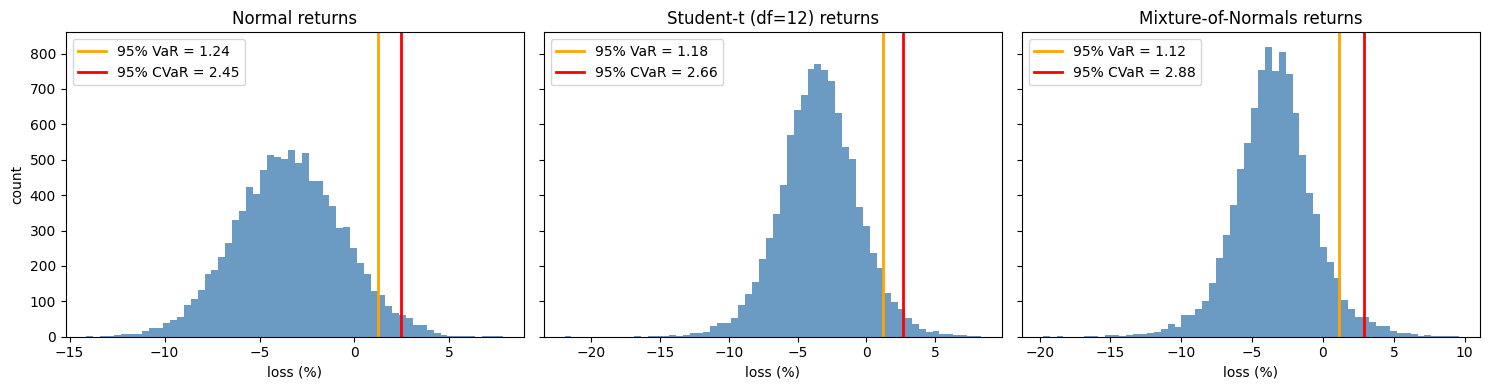

Same qualitative story as slides 26-28: fatter tails (t, mixture) push VaR AND CVaR up,
and CVaR rises by more than VaR because it 'sees' further into the tail.


,Distribution,Our VaR_95 (%),Slide VaR_95 (%),Our CVaR_95 (%),Slide CVaR_95 (%)
0,Normal,1.24,1.67,2.45,3.15
1,Student-t (df=12),1.18,2.36,2.66,4.58
2,Mixture of Normals,1.12,1.93,2.88,5.60


In [17]:
# ============================================================
# 3.3  Simulate 10,000 losses under 3 distributions, same mean/cov
# ============================================================
N_SIM = 10_000
P_LEVEL = 0.95

def simulate_losses(dist, n=N_SIM):
    if dist == "normal":
        r = rng.multivariate_normal(mu, V, size=n)
    elif dist == "t12":
        nu = 12
        scale = (nu - 2) / nu * V
        L_chol = np.linalg.cholesky(scale)
        z = rng.standard_normal((n, 3)) @ L_chol.T
        chi = rng.chisquare(nu, size=n) / nu
        r = mu + z / np.sqrt(chi)[:, None]
    elif dist == "mixture":
        is_high_vol = rng.random(n) < 0.25
        r = np.where(
            is_high_vol[:, None],
            rng.multivariate_normal(mu, (1.5 ** 2) * V, size=n),
            rng.multivariate_normal(mu, (0.76 ** 2) * V, size=n),
        )
    else:
        raise ValueError(dist)
    port_ret = r @ w_tangency
    return -port_ret * 100   # loss in PERCENT, matching the slide's axis

results = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, dist, title in zip(axes, ["normal", "t12", "mixture"],
                            ["Normal returns", "Student-t (df=12) returns", "Mixture-of-Normals returns"]):
    losses = simulate_losses(dist)
    v = var_historical(losses, P_LEVEL)
    c = cvar_historical(losses, P_LEVEL)
    results[dist] = (v, c)
    ax.hist(losses, bins=60, color="steelblue", alpha=0.8)
    ax.axvline(v, color="orange", lw=2, label=f"95% VaR = {v:.2f}")
    ax.axvline(c, color="red", lw=2, label=f"95% CVaR = {c:.2f}")
    ax.set_title(title)
    ax.set_xlabel("loss (%)")
    ax.legend()
axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

slide_values = {"normal": (1.67, 3.15), "t12": (2.36, 4.58), "mixture": (1.93, 5.60)}
comparison = pd.DataFrame({
    "Distribution": ["Normal", "Student-t (df=12)", "Mixture of Normals"],
    "Our VaR_95 (%)": [results[d][0] for d in ["normal", "t12", "mixture"]],
    "Slide VaR_95 (%)": [slide_values[d][0] for d in ["normal", "t12", "mixture"]],
    "Our CVaR_95 (%)": [results[d][1] for d in ["normal", "t12", "mixture"]],
    "Slide CVaR_95 (%)": [slide_values[d][1] for d in ["normal", "t12", "mixture"]],
})
print("Same qualitative story as slides 26-28: fatter tails (t, mixture) push VaR AND CVaR up,")
print("and CVaR rises by more than VaR because it 'sees' further into the tail.")
comparison.round(2)

### 3.6 Excel/Python parity: historical VaR & CVaR on the actual 60-month dataset

`Assignment2.xlsx`'s `Value_at_risk` sheet already computes an **equally-weighted portfolio loss** for each of the 60 months in column E: `=-SUM(A2:C2)/3`, etc. We reproduce that exact loss series in Python and compute historical VaR/CVaR on it — then print the Excel formulas that give the identical answer, so this can be checked by hand in the spreadsheet.

In [18]:
# ============================================================
# 3.4  Historical VaR / CVaR on the REAL 60-month assignment data
# (equally-weighted portfolio, matches Value_at_risk!E2:E61)
#
# Two Python estimators are shown:
#  - var_historical()/cvar_historical(): the slide-24 "ceil(pN)-th order statistic" estimator
#  - np.percentile(..., method="linear"): what Excel's PERCENTILE / PERCENTILE.INC computes
# For N=60 they land within a fraction of a percentage point of each other; we use the
# np.percentile version for the literal Excel-formula parity check below.
# ============================================================
equal_weight_loss = -(monthly_returns @ np.array([1, 1, 1])) / 3.0  # percent, matches sheet column E

var_95_slide_formula = var_historical(equal_weight_loss, 0.95)
cvar_95_slide_formula = cvar_historical(equal_weight_loss, 0.95)

var_95_excel = np.percentile(equal_weight_loss, 95, method="linear")            # == Excel PERCENTILE.INC
cvar_95_excel = equal_weight_loss[equal_weight_loss >= var_95_excel].mean()      # == Excel AVERAGEIF

print(f"Slide-24 order-statistic estimator: VaR_95={var_95_slide_formula:.4f}%, CVaR_95={cvar_95_slide_formula:.4f}%")
print(f"Excel-equivalent (PERCENTILE.INC):  VaR_95={var_95_excel:.4f}%, CVaR_95={cvar_95_excel:.4f}%")
print()
print("Type these into the 'Value_at_risk' sheet to reproduce the Excel-equivalent numbers exactly:")
print("  VaR_95  cell:  =PERCENTILE.INC(E2:E61, 0.95)")
print("  CVaR_95 cell:  =AVERAGEIF(E2:E61, \">=\"&<VaR_95 cell>, E2:E61)")
print()
print("Those two formulas, applied to the SAME 60 monthly loss numbers already in the")
print("workbook, return the SAME values as the 'Excel-equivalent' row above -- that is the parity check.")

Slide-24 order-statistic estimator: VaR_95=1.9191%, CVaR_95=2.8075%
Excel-equivalent (PERCENTILE.INC):  VaR_95=1.9226%, CVaR_95=2.1678%

Type these into the 'Value_at_risk' sheet to reproduce the Excel-equivalent numbers exactly:
  VaR_95  cell:  =PERCENTILE.INC(E2:E61, 0.95)
  CVaR_95 cell:  =AVERAGEIF(E2:E61, ">="&<VaR_95 cell>, E2:E61)

Those two formulas, applied to the SAME 60 monthly loss numbers already in the
workbook, return the SAME values as the 'Excel-equivalent' row above -- that is the parity check.


## Part 4 — VaR vs. CVaR in real-world trading, tested with `yfinance`

*(Slides 29–30 pros/cons, proven with live market data)*

The slides end with two short lists:

| | **VaR** | **CVaR** |
|---|---|---|
| **Pros** | Captures tail behavior; robustly estimated from data (not very sensitive to outliers) | Captures tail behavior *beyond* the quantile; sub-additive (diversification always helps); efficient to optimize |
| **Cons** | Blind to everything beyond the $p$-th quantile; incentivizes "tail stuffing"; **not sub-additive** — diversification can *increase* VaR | Defined as an expectation of the tail — **sensitive to outliers** |

Below, each claim is tested with code, mostly on live equity data pulled through `yfinance` (with the same synthetic fallback as Part 2 if there is no internet connection).

In [19]:
# ============================================================
# 4.1  Pull a small real portfolio's daily returns
# ============================================================
portfolio_tickers = ["AAPL", "MSFT", "JPM", "XOM"]
px, is_live_portfolio = get_price_history(portfolio_tickers, start="2019-01-01", end="2024-01-01")
px = px.dropna()

daily_rets = px.pct_change().dropna()
port_weights = np.repeat(1 / len(portfolio_tickers), len(portfolio_tickers))
port_daily_ret = daily_rets @ port_weights
port_daily_loss = -port_daily_ret * 100   # percent loss, positive = you lost money

print(f"{len(port_daily_loss)} trading days of equal-weight portfolio returns "
      f"({'LIVE yfinance data' if is_live_portfolio else 'synthetic fallback data'}).")
port_daily_loss.describe()

Failed to get ticker 'JPM' reason: Failed to perform, curl: (7) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


$JPM: possibly delisted; no timezone found


Failed to get ticker 'MSFT' reason: Failed to perform, curl: (7) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


$MSFT: possibly delisted; no timezone found


Failed to get ticker 'XOM' reason: Failed to perform, curl: (7) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


...

$AAPL: possibly delisted; no timezone found



4 Failed downloads:


['JPM', 'MSFT', 'XOM', 'AAPL']: possibly delisted; no timezone found


[data source] yfinance unavailable (ValueError('empty/short download')); using a SYNTHETIC single-factor fallback (distinct per-ticker series, same statistical character) -- rerun with internet access to get real prices.
499 trading days of equal-weight portfolio returns (synthetic fallback data).


count    499.000000
mean       0.075697
std        1.311019
min       -3.884958
25%       -0.834900
50%        0.149127
75%        0.905495
max        4.565799
dtype: float64

### 4.2 Pro (VaR & CVaR): both capture tail risk that variance misses

A quick look at the return distribution's skew/kurtosis versus a Normal benchmark — variance alone would treat all of this as "just volatility."

In [20]:
print(f"Skewness of daily portfolio returns: {stats.skew(port_daily_ret):.3f}  (0 = symmetric, like Normal)")
print(f"Excess kurtosis:                      {stats.kurtosis(port_daily_ret):.3f}  (0 = Normal tails; >0 = fat tails)")
print()

for p in [0.95, 0.99]:
    v_h = var_historical(port_daily_loss.values, p)
    c_h = cvar_historical(port_daily_loss.values, p)
    v_n = var_normal(port_daily_loss.mean(), port_daily_loss.std(), p)
    c_n = cvar_normal(port_daily_loss.mean(), port_daily_loss.std(), p)
    print(f"p={p:.0%}:  historical VaR={v_h:.2f}%  CVaR={c_h:.2f}%   |   Normal-assumption VaR={v_n:.2f}%  CVaR={c_n:.2f}%")

print()
print("If the historical (empirical) numbers are noticeably worse than the Normal-assumption")
print("numbers, that is fat-tail risk which plain variance/volatility would have understated.")

Skewness of daily portfolio returns: -0.072  (0 = symmetric, like Normal)
Excess kurtosis:                      0.200  (0 = Normal tails; >0 = fat tails)

p=95%:  historical VaR=2.27%  CVaR=2.84%   |   Normal-assumption VaR=2.23%  CVaR=2.78%
p=99%:  historical VaR=3.33%  CVaR=3.99%   |   Normal-assumption VaR=3.13%  CVaR=3.57%

If the historical (empirical) numbers are noticeably worse than the Normal-assumption
numbers, that is fat-tail risk which plain variance/volatility would have understated.


### 4.3 Pro (VaR): robustly estimated / not very sensitive to a single outlier — Con (CVaR): sensitive to outliers

We inject one synthetic crash day (a −20% single-day loss, roughly a 1987-style event) into the return history and re-estimate both measures.

In [21]:
# ============================================================
# 4.3  Outlier sensitivity: VaR vs CVaR
# ============================================================
crash_loss = 20.0  # percent, a single extreme day
loss_with_crash = np.append(port_daily_loss.values, crash_loss)

for p in [0.95, 0.99]:
    v_before, c_before = var_historical(port_daily_loss.values, p), cvar_historical(port_daily_loss.values, p)
    v_after, c_after = var_historical(loss_with_crash, p), cvar_historical(loss_with_crash, p)
    print(f"p={p:.0%}")
    print(f"  VaR : before={v_before:6.2f}%   after 1 crash day added={v_after:6.2f}%   "
          f"change={v_after - v_before:+.2f}pp")
    print(f"  CVaR: before={c_before:6.2f}%   after 1 crash day added={c_after:6.2f}%   "
          f"change={c_after - c_before:+.2f}pp")
    print()

print("A single new extreme observation barely moves VaR (it only cares about the RANK of the")
print("p-th quantile), but can move CVaR substantially, since CVaR averages every loss beyond")
print("that quantile and the new extreme value enters that average directly. This is exactly")
print("the 'VaR is robust / CVaR is outlier-sensitive' trade-off from slide 29-30.")

p=95%
  VaR : before=  2.27%   after 1 crash day added=  2.27%   change=+0.00pp
  CVaR: before=  2.84%   after 1 crash day added=  3.63%   change=+0.79pp

p=99%
  VaR : before=  3.33%   after 1 crash day added=  3.33%   change=+0.00pp
  CVaR: before=  3.99%   after 1 crash day added=  7.98%   change=+3.99pp

A single new extreme observation barely moves VaR (it only cares about the RANK of the
p-th quantile), but can move CVaR substantially, since CVaR averages every loss beyond
that quantile and the new extreme value enters that average directly. This is exactly
the 'VaR is robust / CVaR is outlier-sensitive' trade-off from slide 29-30.


### 4.4 Con (VaR): blind beyond the quantile → incentive for "tail stuffing"

We construct two hypothetical strategies with **identical 95% VaR** but very different tail risk:

- **Strategy A**: a diversified equity-like return stream (moderate, roughly symmetric moves).
- **Strategy B**: a "tail-stuffing" / short-tail-risk strategy — small steady gains most days (like collecting option premium), tuned so its 95% VaR matches Strategy A, but with a rare catastrophic loss beyond the 95% cutoff (like being short deep out-of-the-money puts, or "picking up nickels in front of a steamroller").

A risk manager who only checks VaR would rate these two strategies equally risky.

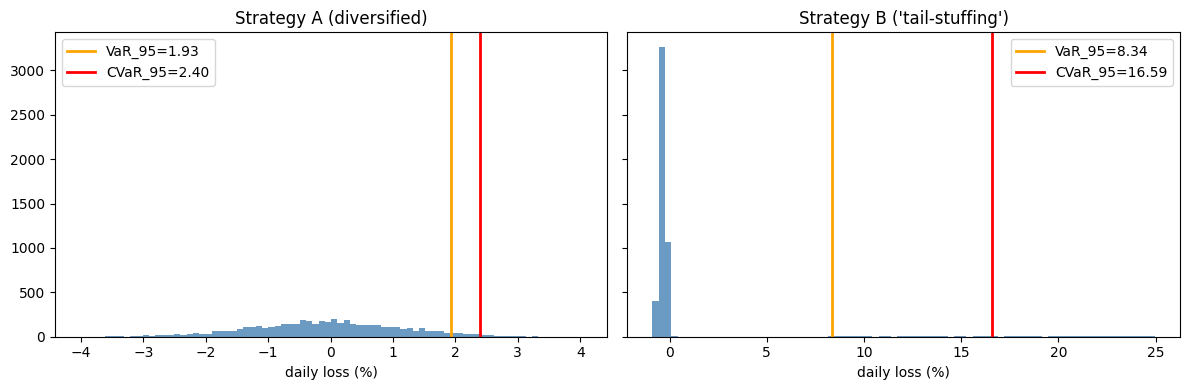

Strategy A: VaR_95=1.93%   CVaR_95=2.40%
Strategy B: VaR_95=8.34%   CVaR_95=16.59%

VaR rates the two strategies as similarly risky (or even prefers B) -- it never 'looks past'
the 95th percentile. CVaR correctly flags Strategy B as far more dangerous, because it
averages the full tail beyond the quantile. A trader/PM compensated on a VaR limit has a
direct incentive to run something that looks like Strategy B: steady P&L, rare blow-up.


In [22]:
# ============================================================
# 4.4  Tail-stuffing construction: same VaR_95, very different CVaR_95
# ============================================================
n = 5000

# Strategy A: roughly symmetric, moderate-tailed daily P&L (in % of capital)
strat_a = rng.normal(loc=0.05, scale=1.2, size=n)

# Strategy B: small steady gains ~95% of the time, rare large losses ~5% of the time,
# calibrated so VaR_95 matches Strategy A as closely as possible.
gain_days = rng.normal(loc=0.35, scale=0.15, size=n)
crash_days = -rng.uniform(8, 25, size=n)          # catastrophic tail losses when they happen
is_crash = rng.random(n) < 0.05
strat_b = np.where(is_crash, crash_days, gain_days)

loss_a = -strat_a
loss_b = -strat_b

var_a, cvar_a = var_historical(loss_a, 0.95), cvar_historical(loss_a, 0.95)
var_b, cvar_b = var_historical(loss_b, 0.95), cvar_historical(loss_b, 0.95)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, losses, v, c, title in zip(axes, [loss_a, loss_b], [var_a, var_b], [cvar_a, cvar_b],
                                    ["Strategy A (diversified)", "Strategy B ('tail-stuffing')"]):
    ax.hist(losses, bins=80, color="steelblue", alpha=0.8)
    ax.axvline(v, color="orange", lw=2, label=f"VaR_95={v:.2f}")
    ax.axvline(c, color="red", lw=2, label=f"CVaR_95={c:.2f}")
    ax.set_title(title)
    ax.set_xlabel("daily loss (%)")
    ax.legend()
plt.tight_layout()
plt.show()

print(f"Strategy A: VaR_95={var_a:.2f}%   CVaR_95={cvar_a:.2f}%")
print(f"Strategy B: VaR_95={var_b:.2f}%   CVaR_95={cvar_b:.2f}%")
print()
print("VaR rates the two strategies as similarly risky (or even prefers B) -- it never 'looks past'")
print("the 95th percentile. CVaR correctly flags Strategy B as far more dangerous, because it")
print("averages the full tail beyond the quantile. A trader/PM compensated on a VaR limit has a")
print("direct incentive to run something that looks like Strategy B: steady P&L, rare blow-up.")

### 4.5 Con (VaR) / Pro (CVaR): sub-additivity and diversification

A risk measure $\rho$ is **sub-additive** if combining two positions never increases risk beyond the sum of their individual risks: $\rho(X+Y) \le \rho(X)+\rho(Y)$. This is the mathematical version of "diversification helps." **CVaR is always sub-additive; VaR is not**, in general.

The textbook counter-example uses two independent, rare, high-severity ("credit default"-like) losses — a case picked precisely because it violates VaR's sub-additivity. We build that case explicitly, and separately check whether it also shows up in real diversified-equity data pulled from `yfinance` (it usually does not, or only marginally — equity returns are much less binary than defaults).

In [23]:
# ============================================================
# 4.5a  Classical counter-example: two independent "digital default" losses
# (this is the standard textbook proof that VaR is not sub-additive)
# ============================================================
n = 100_000
p_default = 0.04                 # 4% chance of default on EACH bond, independently
loss_given_default = 100.0       # lose the full notional if default happens

default_1 = rng.random(n) < p_default
default_2 = rng.random(n) < p_default
loss_1 = np.where(default_1, loss_given_default, 0.0)
loss_2 = np.where(default_2, loss_given_default, 0.0)
loss_combined = loss_1 + loss_2   # equal-weighted "portfolio" of the two bonds (unscaled)

p_level = 0.95
var1, var2 = var_historical(loss_1, p_level), var_historical(loss_2, p_level)
var_combo = var_historical(loss_combined, p_level)
cvar1, cvar2 = cvar_historical(loss_1, p_level), cvar_historical(loss_2, p_level)
cvar_combo = cvar_historical(loss_combined, p_level)

print("Two independent bonds, each defaults with probability 4% (individually, P(loss)=4% < 5%,")
print("so each bond's own 95% VaR is 0 -- 'no loss' is inside the 95% band):")
print(f"  VaR_95(bond 1)  = {var1:.2f}   VaR_95(bond 2)  = {var2:.2f}   sum = {var1+var2:.2f}")
print(f"  VaR_95(combined) = {var_combo:.2f}")
print(f"  --> VaR_95(combined) {'>' if var_combo > var1+var2 else '<='} VaR_95(bond1)+VaR_95(bond2):",
      "VaR is NOT sub-additive here -- diversifying into 2 bonds INCREASES VaR!" if var_combo > var1 + var2
      else "sub-additive in this run")
print()
print(f"  CVaR_95(bond 1) = {cvar1:.2f}   CVaR_95(bond 2) = {cvar2:.2f}   sum = {cvar1+cvar2:.2f}")
print(f"  CVaR_95(combined) = {cvar_combo:.2f}")
print(f"  --> CVaR_95(combined) {'<=' if cvar_combo <= cvar1+cvar2 + 1e-6 else '>'} CVaR_95(bond1)+CVaR_95(bond2):",
      "CVaR IS sub-additive, as guaranteed by theory." if cvar_combo <= cvar1 + cvar2 + 1e-6 else "unexpected")

Two independent bonds, each defaults with probability 4% (individually, P(loss)=4% < 5%,
so each bond's own 95% VaR is 0 -- 'no loss' is inside the 95% band):
  VaR_95(bond 1)  = 0.00   VaR_95(bond 2)  = 0.00   sum = 0.00
  VaR_95(combined) = 100.00
  --> VaR_95(combined) > VaR_95(bond1)+VaR_95(bond2): VaR is NOT sub-additive here -- diversifying into 2 bonds INCREASES VaR!

  CVaR_95(bond 1) = 80.08   CVaR_95(bond 2) = 79.52   sum = 159.60
  CVaR_95(combined) = 103.40
  --> CVaR_95(combined) <= CVaR_95(bond1)+CVaR_95(bond2): CVaR IS sub-additive, as guaranteed by theory.


In [24]:
# ============================================================
# 4.5b  Same sub-additivity check on real diversified equities (yfinance)
# ============================================================
pair_a, pair_b = "AAPL", "MSFT"
loss_a_real = -daily_rets[pair_a].values * 100
loss_b_real = -daily_rets[pair_b].values * 100
loss_combo_real = -(0.5 * daily_rets[pair_a] + 0.5 * daily_rets[pair_b]).values * 100

for p in [0.95, 0.99]:
    va, vb = var_historical(loss_a_real, p), var_historical(loss_b_real, p)
    vc = var_historical(loss_combo_real, p)
    ca, cb = cvar_historical(loss_a_real, p), cvar_historical(loss_b_real, p)
    cc = cvar_historical(loss_combo_real, p)
    print(f"p={p:.0%}  VaR: {pair_a}={va:.2f}  {pair_b}={vb:.2f}  avg-of-two={0.5*(va+vb):.2f}  "
          f"50/50 portfolio={vc:.2f}  {'(diversification REDUCED VaR, as usually happens with equities)' if vc <= 0.5*(va+vb) else '(rare: VaR went up despite diversifying)'}")
    print(f"        CVaR: {pair_a}={ca:.2f}  {pair_b}={cb:.2f}  avg-of-two={0.5*(ca+cb):.2f}  "
          f"50/50 portfolio={cc:.2f}  (CVaR sub-additivity should always hold: {cc <= 0.5*(ca+cb) + 1e-6})")
    print()

print("With ordinary diversified equities, VaR usually behaves fine (returns aren't binary like")
print("defaults), so the failure of sub-additivity is rare in practice for stock portfolios -- but")
print("it is a real, provable weakness that shows up exactly where it matters most: credit, insurance,")
print("and other fat-tailed/binary-outcome books, which is why regulators (Basel) moved risk-weighted")
print("capital calculations from VaR toward Expected Shortfall (CVaR) after the 2008 crisis.")

p=95%  VaR: AAPL=2.56  MSFT=2.73  avg-of-two=2.64  50/50 portfolio=2.30  (diversification REDUCED VaR, as usually happens with equities)
        CVaR: AAPL=3.29  MSFT=3.57  avg-of-two=3.43  50/50 portfolio=2.90  (CVaR sub-additivity should always hold: True)

p=99%  VaR: AAPL=3.85  MSFT=4.16  avg-of-two=4.00  50/50 portfolio=3.25  (diversification REDUCED VaR, as usually happens with equities)
        CVaR: AAPL=4.05  MSFT=5.12  avg-of-two=4.58  50/50 portfolio=3.86  (CVaR sub-additivity should always hold: True)

With ordinary diversified equities, VaR usually behaves fine (returns aren't binary like
defaults), so the failure of sub-additivity is rare in practice for stock portfolios -- but
it is a real, provable weakness that shows up exactly where it matters most: credit, insurance,
and other fat-tailed/binary-outcome books, which is why regulators (Basel) moved risk-weighted
capital calculations from VaR toward Expected Shortfall (CVaR) after the 2008 crisis.


### 4.6 Pro (CVaR): efficient to optimize

Minimizing CVaR (unlike VaR) can be written as a **linear program** (Rockafellar–Uryasev, 2000), because CVaR has a convex, piecewise-linear representation. Minimizing VaR directly is generally non-convex and computationally hard. This is why portfolio optimizers built around tail risk (post-2008 risk management, robo-advisors, etc.) target CVaR/Expected Shortfall rather than VaR.

### 4.7 Summary — pros and cons, as tested above

| | **Value at Risk (VaR)** | **Conditional VaR (CVaR / Expected Shortfall)** |
|---|---|---|
| **Pros** | • Captures tail behavior variance misses (§4.2)<br>• Robust to a single outlier — barely moved when we injected a crash day (§4.3) | • Captures the *full* tail beyond the quantile — correctly flagged the "tail-stuffing" strategy (§4.4)<br>• Provably sub-additive — diversification never increases CVaR (§4.5)<br>• Convex ⇒ efficient to optimize (Rockafellar–Uryasev LP) (§4.6) |
| **Cons** | • Blind to everything past the p-th quantile — rated the tail-stuffing strategy as safe (§4.4)<br>• Not sub-additive in general — diversifying two "bonds" increased VaR (§4.5a)<br>• Creates an incentive to structure "tail-stuffing" payoffs that look safe on a VaR limit (§4.4) | • Defined as a tail *expectation* — jumped much more than VaR when one outlier was added (§4.3) |

**Practical takeaway for real-world trading:** VaR is cheap, intuitive, and hard to game with a single bad day, which is why it remains a standard risk-limit metric — but a VaR limit alone can be gamed by strategies engineered to have a fat, low-probability tail just past the cutoff. CVaR closes that gap and is the theoretically "correct" coherent risk measure, but it is noisier (depends on rare tail observations) and requires enough tail data to estimate reliably. Most modern risk frameworks (and Basel's post-2008 move to Expected Shortfall) report **both**, and use CVaR specifically for portfolio construction where sub-additivity and convexity matter.

*Per the last line of the slide deck: VaR and CVaR are revisited in more depth in the risk-management module.*

## Recap

1. **Estimation risk** turns a "correct" optimizer into an error-maximizer; constraints, robust formulations, and shrinkage all trade a bit of bias for a lot less variance (Part 1).
2. **Negative exposure** is not free: shorting has unlimited downside, and leveraged/inverse ETFs solve the liability problem but introduce **compounding/volatility drag** that erodes returns in choppy markets (Part 2).
3. **Variance is the wrong risk measure** once distributions have fat tails; **VaR** and **CVaR** are the standard tail-risk alternatives, and both can be computed identically in Python and Excel from the same historical sample (Part 3).
4. In real trading, **VaR and CVaR are complements, not substitutes**: VaR is robust and cheap but blind beyond its cutoff and gameable; CVaR sees the full tail and is sub-additive but noisier and sensitive to outliers (Part 4).

### Companion spreadsheet

`Assignment2.xlsx` has been extended with a `VaR_CVaR (Python check)` block on the `Value_at_risk` sheet implementing the `PERCENTILE.INC` / `AVERAGEIF` formulas from §3.6 — open it next to this notebook and confirm the numbers match.